#SARIMA Forecasting of Online Retail Revenue

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##Dataset Loading And Preparation

##Dataset

The SARIMA model exploration utilises the **Online Retail Dataset** from the UCI Machine Learning Repository. The data consists of invoice data from a UK-based retailer between December 2010 and December 2011.

Source: UCI Machine Learning Repository
Link: https://archive.ics.uci.edu/dataset/352/online+retail

The project focuses on developing a stronger baseline model which extends the previous ARIMA model which did not capture any seasonal structure while capturing the. Which is done by introducing SARIMA to eveluate whether the seasonal components improve forecasting performance for weekly revenue.

In [ ]:
dataset = pd.read_excel("./Online Retail.xlsx")

In [ ]:
dataset.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


###Data Preprocessing

In [ ]:
print(f"Negative Price: {dataset[dataset['UnitPrice'] < 0].shape}")

Negative Price: (2, 8)


In [ ]:
print(dataset[dataset['UnitPrice'] < 0])

       InvoiceNo StockCode      Description  Quantity         InvoiceDate  \
299983   A563186         B  Adjust bad debt         1 2011-08-12 14:51:00   
299984   A563187         B  Adjust bad debt         1 2011-08-12 14:52:00   

        UnitPrice  CustomerID         Country  
299983  -11062.06         NaN  United Kingdom  
299984  -11062.06         NaN  United Kingdom  


In [ ]:
print(f"Negative Quantity: {dataset[dataset['Quantity'] < 0].shape}")

Negative Quantity: (10624, 8)


In [ ]:
print(dataset[dataset['Quantity'] < 0])

       InvoiceNo StockCode                       Description  Quantity  \
141      C536379         D                          Discount        -1   
154      C536383    35004C   SET OF 3 COLOURED  FLYING DUCKS        -1   
235      C536391     22556    PLASTERS IN TIN CIRCUS PARADE        -12   
236      C536391     21984  PACK OF 12 PINK PAISLEY TISSUES        -24   
237      C536391     21983  PACK OF 12 BLUE PAISLEY TISSUES        -24   
...          ...       ...                               ...       ...   
540449   C581490     23144   ZINC T-LIGHT HOLDER STARS SMALL       -11   
541541   C581499         M                            Manual        -1   
541715   C581568     21258        VICTORIAN SEWING BOX LARGE        -5   
541716   C581569     84978  HANGING HEART JAR T-LIGHT HOLDER        -1   
541717   C581569     20979     36 PENCILS TUBE RED RETROSPOT        -5   

               InvoiceDate  UnitPrice  CustomerID         Country  
141    2010-12-01 09:41:00      27.50     1

In [ ]:
print(f"Null Values: {dataset.isnull().sum()}")

Null Values: InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [ ]:
counts = dataset['InvoiceNo'].value_counts()
print(f"Duplicate invoices: {counts[counts>1]}")

Duplicate invoices: InvoiceNo
573585     1114
581219      749
581492      731
580729      721
558475      705
           ... 
C555596       2
551401        2
C551335       2
551334        2
560416        2
Name: count, Length: 20059, dtype: int64


In [ ]:
null_id_mask = dataset[dataset['CustomerID'].isnull()]

In [ ]:
print(null_id_mask)

       InvoiceNo StockCode                      Description  Quantity  \
622       536414     22139                              NaN        56   
1443      536544     21773  DECORATIVE ROSE BATHROOM BOTTLE         1   
1444      536544     21774  DECORATIVE CATS BATHROOM BOTTLE         2   
1445      536544     21786               POLKADOT RAIN HAT          4   
1446      536544     21787            RAIN PONCHO RETROSPOT         2   
...          ...       ...                              ...       ...   
541536    581498    85099B          JUMBO BAG RED RETROSPOT         5   
541537    581498    85099C   JUMBO  BAG BAROQUE BLACK WHITE         4   
541538    581498     85150    LADIES & GENTLEMEN METAL SIGN         1   
541539    581498     85174                S/4 CACTI CANDLES         1   
541540    581498       DOT                   DOTCOM POSTAGE         1   

               InvoiceDate  UnitPrice  CustomerID         Country  
622    2010-12-01 11:52:00       0.00         NaN  Unit

In [ ]:
null_description_mask = dataset[dataset['Description'].isnull()]

In [ ]:
null_description_mask.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


In [ ]:
null_description_mask.shape

(1454, 8)

In [ ]:
unit_price_mask = dataset[dataset['UnitPrice'] == 0]

In [ ]:
unit_price_mask.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


In [ ]:
unit_price_mask.shape

(2515, 8)

In [ ]:
dataset.groupby('StockCode')['Description'].apply(
    lambda x: x.isna().all()
).value_counts()

,count
Description,
False,3958
True,112


In [ ]:
dataset['Description'] = (
    dataset.groupby('StockCode')['Description']
           .transform(lambda x: x.ffill().bfill())
)

/tmp/ipykernel_1235/2971329427.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .transform(lambda x: x.ffill().bfill())


In [ ]:
dataset[dataset['Description'].isnull()].shape

(112, 8)

In [ ]:
dataset.groupby('StockCode')['UnitPrice'].apply(
    lambda x: (x == 0).all()
).value_counts()

,count
UnitPrice,
False,3938
True,132


In [ ]:
dataset['UnitPrice'] = (
    dataset.groupby('StockCode')['UnitPrice']
           .transform(lambda x: x.replace(0, np.nan).ffill().bfill())
)

In [ ]:
dataset[dataset['UnitPrice'].isnull()].shape

(134, 8)

In [ ]:
unknown_stock = dataset[dataset['UnitPrice'].isnull() & dataset['Description'].isnull()]
dataset = dataset[dataset['Description'].notna()]

In [ ]:
unknown_customer = dataset[dataset['CustomerID'].isnull()]
print(unknown_customer.head(5))

     InvoiceNo StockCode                       Description  Quantity  \
622     536414     22139  RETROSPOT TEA SET CERAMIC 11 PC         56   
1443    536544     21773   DECORATIVE ROSE BATHROOM BOTTLE         1   
1444    536544     21774   DECORATIVE CATS BATHROOM BOTTLE         2   
1445    536544     21786                POLKADOT RAIN HAT          4   
1446    536544     21787             RAIN PONCHO RETROSPOT         2   

             InvoiceDate  UnitPrice  CustomerID         Country  
622  2010-12-01 11:52:00       4.25         NaN  United Kingdom  
1443 2010-12-01 14:32:00       2.51         NaN  United Kingdom  
1444 2010-12-01 14:32:00       2.51         NaN  United Kingdom  
1445 2010-12-01 14:32:00       0.85         NaN  United Kingdom  
1446 2010-12-01 14:32:00       1.66         NaN  United Kingdom  


In [ ]:
dataset.groupby(dataset['CustomerID'].notna())['InvoiceNo'].nunique()

,InvoiceNo
CustomerID,
False,3598
True,22190


In [ ]:
dataset[dataset['UnitPrice'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
51049,540638,72038P,damages,-990,2011-01-10 12:14:00,NaN,NaN,United Kingdom
82794,543257,84611B,thrown away,-1430,2011-02-04 16:06:00,NaN,NaN,United Kingdom
82795,543258,84611B,thrown away,1287,2011-02-04 16:06:00,NaN,NaN,United Kingdom
82796,543259,84612B,thrown away,-162,2011-02-04 16:07:00,NaN,NaN,United Kingdom
115489,546126,35611B,thrown away,-27,2011-03-09 14:52:00,NaN,NaN,United Kingdom
115818,546152,72140F,throw away,-5368,2011-03-09 17:25:00,NaN,NaN,United Kingdom
131398,547559,72759,thrown away-can't sell.,-524,2011-03-23 17:27:00,NaN,NaN,United Kingdom
131399,547560,72732,thrown away-can't sell,-2472,2011-03-23 17:28:00,NaN,NaN,United Kingdom
185113,552733,23059,Thrown away-rusty,-2376,2011-05-11 10:48:00,NaN,NaN,United Kingdom
254130,559296,23001,TRAVEL CARD WALLET DOTCOMGIFTSHOP,200,2011-07-07 12:35:00,NaN,NaN,United Kingdom


In [ ]:
damages_other = dataset[dataset['UnitPrice'].isnull()]
dataset = dataset[~dataset['UnitPrice'].isnull()]
dataset = dataset[dataset['UnitPrice'] > 0]

In [ ]:
print(f"Null Values: {dataset.isnull().sum()}")

Null Values: InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     134944
Country             0
dtype: int64


In [ ]:
uknown_customer = dataset[dataset['CustomerID'].isnull()]
#dataset = dataset[~dataset['CustomerID'].isnull()]

###Revenue Calculation

Revenue is calculated as Quantity * UnitPrice.

In [ ]:
dataset["TotalPaid"] = dataset["UnitPrice"] * dataset["Quantity"]

In [ ]:
print(f"TotalPaid: Min: {dataset["TotalPaid"].min()} Max: {dataset["TotalPaid"].max()}")

TotalPaid: Min: -168469.6 Max: 184600.0


In [ ]:
print(f"This years revenue: {dataset['TotalPaid'].sum()}")

This years revenue: 9686373.475


##Weekly Agreggation

Since we only have daily data for a one year period the choice of aggregation has been weekly as it allows to form a time series suitable for forecasting.

For detailed exploratory analysis of the dataset, refer to the EDA project:
https://github.com/NewLifeStyle101/OnlineRetailEDA

A 4-week rolling window has been chosen for the 58 week data set as it allows to preserver the trend of the data.

In [ ]:
dataset['InvoiceDate'] = pd.to_datetime(dataset['InvoiceDate'])
dataset['Weekly'] = dataset['InvoiceDate'].dt.to_period('W')
dataset['Weekly'] = dataset['Weekly'].dt.to_timestamp()
product_timeline_weeks = (
    dataset
    .groupby(['StockCode', 'Weekly'])['TotalPaid']
    .sum()
    .reset_index()
)


In [ ]:
top_products = (
    dataset.groupby('StockCode')['TotalPaid']
           .sum()
           .sort_values(ascending=False)
           .head(5)
           .index
)

In [ ]:
revenue_weekly = dataset.groupby('Weekly')['TotalPaid'].sum()

In [ ]:
quantity_per_week = (
    dataset
    .groupby(['Weekly'])['Quantity']
    .sum()
    .reset_index()
    .set_index('Weekly')
)
print(revenue_weekly.dtypes)
print(type(revenue_weekly.index[0]))
print(quantity_per_week.dtypes)
print(type(quantity_per_week.index[0]))

float64
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
Quantity    int64
dtype: object
<class 'pandas._libs.tslibs.timestamps.Timestamp'>


##Before Log Transformation

Text(0.5, 1.0, 'Weekly Revenue')

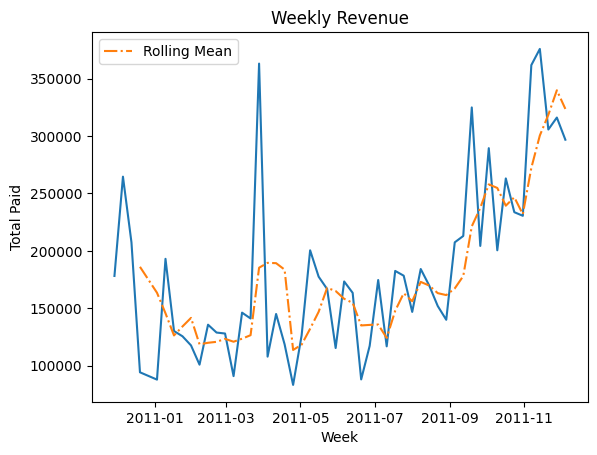

In [ ]:
plt.plot(revenue_weekly.index, revenue_weekly)
mean_per_week_revenue = revenue_weekly.rolling(4).mean()
plt.plot(revenue_weekly.index,mean_per_week_revenue,linestyle="-.",label="Rolling Mean")
plt.legend()
plt.xlabel('Week')
plt.ylabel('Total Paid')
plt.title('Weekly Revenue')

The aggregated revenue time series shows an upward trend and irregular spikes, particularly toward the end of the year. However, no consistent repeating seasonal pattern is visible.

Text(0.5, 1.0, 'Weekly Revenue')

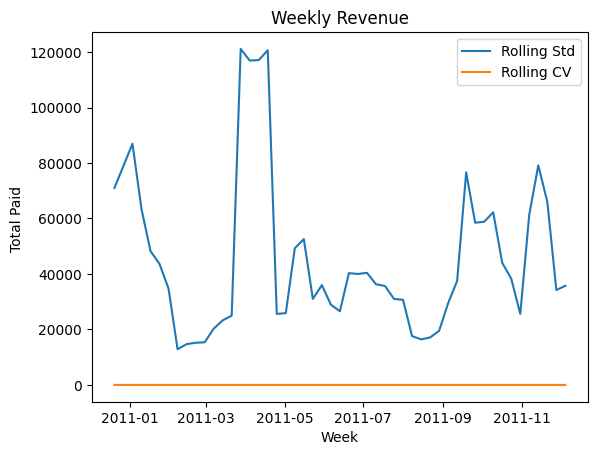

In [ ]:
std_per_week_revenue = revenue_weekly.rolling(4).std()
rolling_cv = std_per_week_revenue / mean_per_week_revenue
plt.plot(revenue_weekly.index,std_per_week_revenue,linestyle="-",label="Rolling Std")
plt.plot(revenue_weekly.index,rolling_cv,linestyle="-",label="Rolling CV")
plt.legend()
plt.xlabel('Week')
plt.ylabel('Total Paid ')
plt.title('Weekly Revenue')

Text(0.5, 1.0, 'Weekly Revenue')

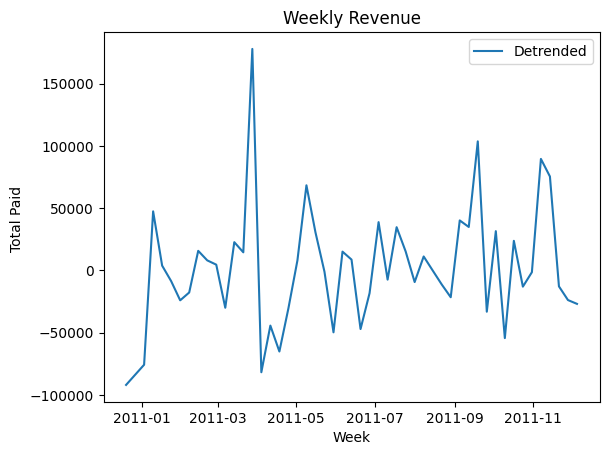

In [ ]:
detrended = revenue_weekly - mean_per_week_revenue
plt.plot(detrended.index,detrended.values,linestyle="-",label="Detrended")
plt.legend()
plt.xlabel('Week')
plt.ylabel('Total Paid ')
plt.title('Weekly Revenue')

In [ ]:
print(revenue_weekly[revenue_weekly.isna()])
print(revenue_weekly.isin([np.inf,-np.inf]).sum())

Series([], Name: TotalPaid, dtype: float64)
0


##After Log Transformation

The log transformation of the revenue is neccessary to stabilize the rolling mean and standard devation.

Text(0.5, 1.0, 'Logarithm of Weekly Revenue')

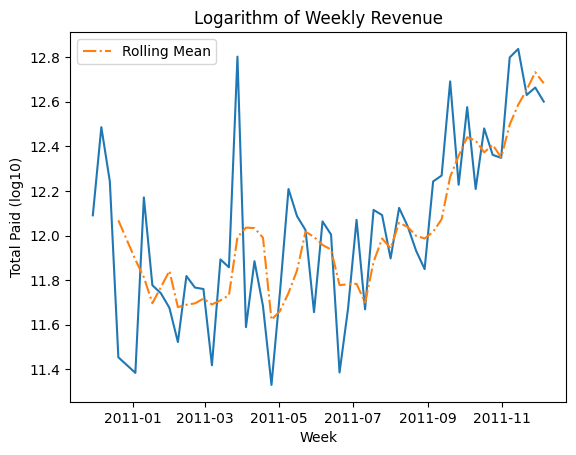

In [ ]:
plt.plot(revenue_weekly.index, np.log(revenue_weekly))
mean_per_week_revenue = np.log(revenue_weekly).rolling(4).mean()
plt.plot(revenue_weekly.index,mean_per_week_revenue,linestyle="-.",label="Rolling Mean")
plt.legend()
plt.xlabel('Week')
plt.ylabel('Total Paid (log10)')
plt.title('Logarithm of Weekly Revenue')

Text(0.5, 1.0, 'Logarithm of Weekly Revenue')

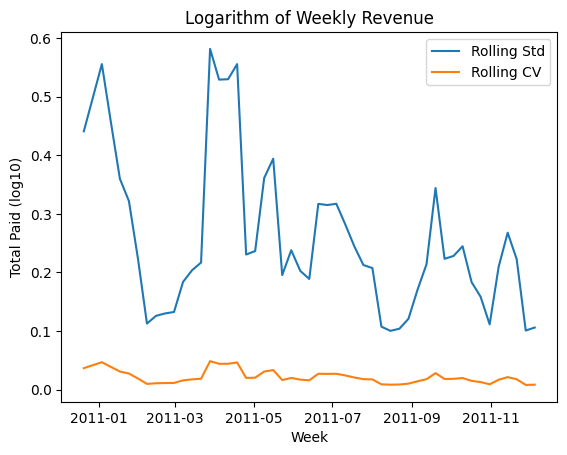

In [ ]:
std_per_week_revenue = np.log(revenue_weekly).rolling(4).std()
rolling_cv = std_per_week_revenue / mean_per_week_revenue
plt.plot(revenue_weekly.index,std_per_week_revenue,linestyle="-",label="Rolling Std")
plt.plot(revenue_weekly.index,rolling_cv,linestyle="-",label="Rolling CV")
plt.legend()
plt.xlabel('Week')
plt.ylabel('Total Paid (log10)')
plt.title('Logarithm of Weekly Revenue')

Text(0.5, 1.0, 'Logarithm of Weekly Revenue')

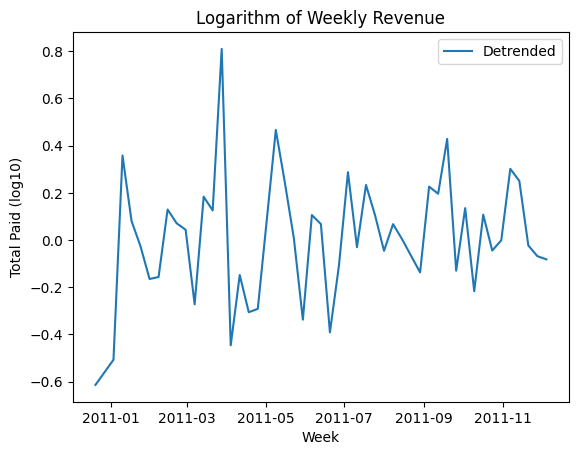

In [ ]:
detrended = np.log(revenue_weekly) - mean_per_week_revenue
plt.plot(detrended.index,detrended.values,linestyle="-",label="Detrended")
plt.legend()
plt.xlabel('Week')
plt.ylabel('Total Paid (log10)')
plt.title('Logarithm of Weekly Revenue')

In [ ]:
print(np.log(revenue_weekly)[np.log(revenue_weekly).isna()])
print(np.log(revenue_weekly).isin([np.inf,-np.inf]).sum())

Series([], Name: TotalPaid, dtype: float64)
0


##After Differencing

As established in the ARIMA project, the series is non-stationary and requires first order differencing to stabilize the mean.

Text(0.5, 1.0, 'Differenced Logarithm of Weekly Revenue')

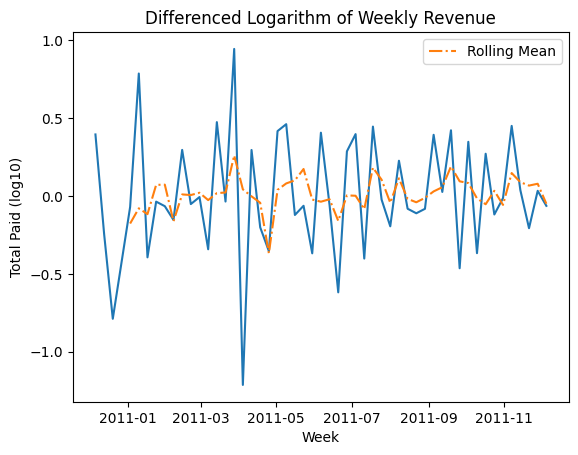

In [ ]:
log_revenue = np.log(revenue_weekly)
log_revenue_diff = log_revenue.diff()
log_revenue_diff = log_revenue_diff.dropna()
plt.plot(log_revenue_diff.index,log_revenue_diff)
mean_per_week_diff_revenue = log_revenue_diff.rolling(4).mean()
plt.plot(log_revenue_diff.index,mean_per_week_diff_revenue,linestyle="-.",label="Rolling Mean")
plt.legend()
plt.xlabel('Week')
plt.ylabel('Total Paid (log10)')
plt.title('Differenced Logarithm of Weekly Revenue')

Text(0.5, 1.0, 'Differenced Logarithm of Weekly Revenue')

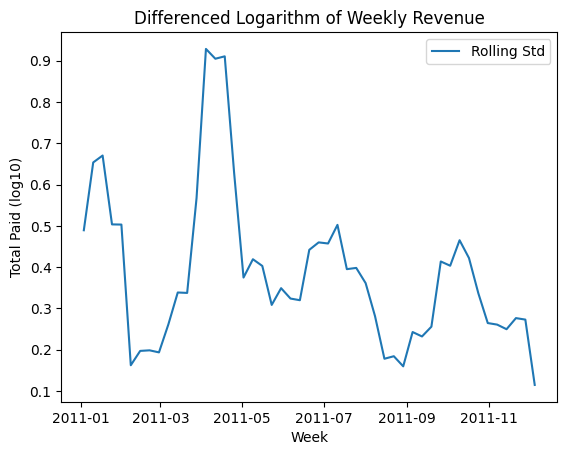

In [ ]:
std_per_week_diff_revenue = log_revenue_diff.rolling(4).std()

plt.plot(log_revenue_diff.index,std_per_week_diff_revenue,linestyle="-",label="Rolling Std")
plt.legend()
plt.xlabel('Week')
plt.ylabel('Total Paid (log10)')
plt.title('Differenced Logarithm of Weekly Revenue')

Text(0.5, 1.0, 'Logarithm of Weekly Revenue')

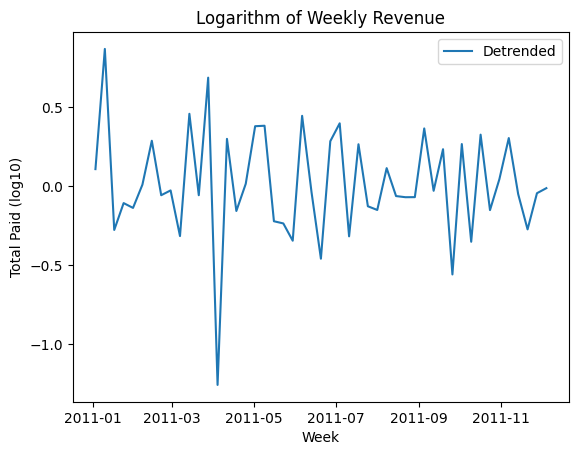

In [ ]:
detrended = log_revenue_diff - mean_per_week_diff_revenue
plt.plot(detrended.index,detrended.values,linestyle="-",label="Detrended")
plt.legend()
plt.xlabel('Week')
plt.ylabel('Total Paid (log10)')
plt.title('Logarithm of Weekly Revenue')

In [ ]:
print(log_revenue_diff[log_revenue_diff.isna()])
print(log_revenue_diff.isin([np.inf,-np.inf]).sum())

Series([], Name: TotalPaid, dtype: float64)
0


##Autocorrelation

In [ ]:
correlation_with_lagged_feature = []
for i in range(0,26):
  lagged_feature = log_revenue_diff.shift(i)
  correlation_with_lagged_feature.append({'Lag': i, 'Correlation':log_revenue_diff.corr(lagged_feature)})
print(type(correlation_with_lagged_feature))
print(type(correlation_with_lagged_feature[0]))
correlation_with_lagged_feature = pd.DataFrame(correlation_with_lagged_feature)
print(correlation_with_lagged_feature)


<class 'list'>
<class 'dict'>
    Lag  Correlation
0     0     1.000000
1     1    -0.416974
2     2    -0.048010
3     3    -0.061201
4     4     0.025565
5     5    -0.068029
6     6     0.149066
7     7    -0.152990
8     8     0.135422
9     9    -0.027324
10   10    -0.041346
11   11     0.310040
12   12    -0.374136
13   13    -0.078694
14   14     0.227582
15   15    -0.148899
16   16     0.084980
17   17     0.189729
18   18    -0.155603
19   19     0.089720
20   20    -0.210792
21   21     0.130462
22   22     0.064915
23   23    -0.174949
24   24    -0.198639
25   25     0.680521


In [ ]:
import statsmodels.api as sm

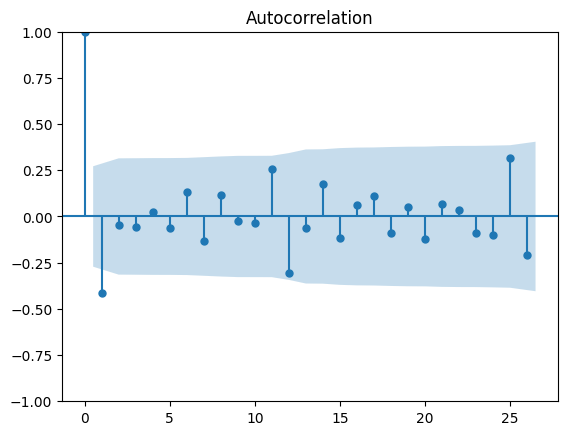

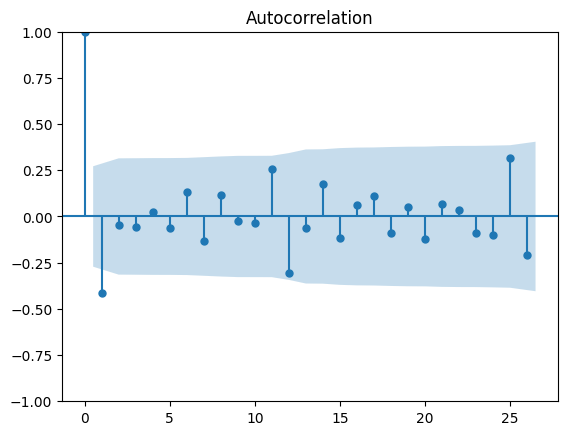

In [ ]:
sm.graphics.tsa.plot_acf(log_revenue_diff,lags=26)

Through the inspection of the acf, we can deduce there is little to non seasonality as there is no significant spikes after lag 1 suggesting that the seasonal component is not driven by random seasonal events.

##Partial Autocorrelation

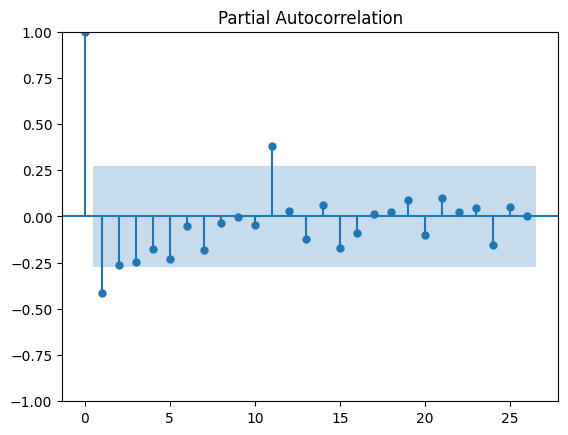

In [ ]:
# Calculate PACF
pacf_values = sm.tsa.pacf(log_revenue_diff, nlags=13)

# Plot PACF
sm.graphics.tsa.plot_pacf(log_revenue_diff, lags=26)
plt.show()

From the inspection of the pacf, we can see there is little to non seasonal autoregressive dependence as there is a clear spike at lag 12. However, this significance does not repeat in lag 24 thus, this means seasonality is not present and the spike at lag 12 could be due to noise or holiday effects therefore, there is no autoregressive structure.

## Seasonal Exploration

No strong seasonal patterns have been identified. However, to improve the previous ARIMA baseline we have conducted a seasonal decomposition to identify any possible seasonal periods (4,8 and 12 weeks).

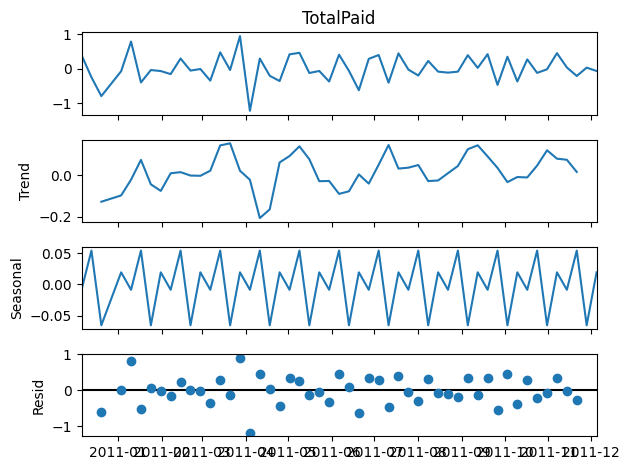

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(log_revenue_diff, period=4)

decomp.plot()
plt.show()

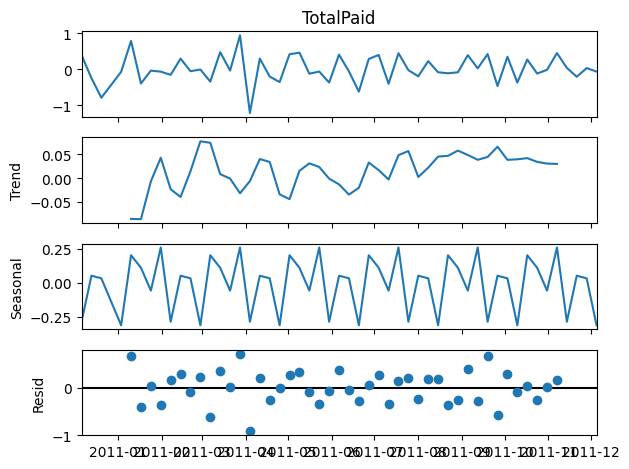

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(log_revenue_diff, period=8)

decomp.plot()
plt.show()

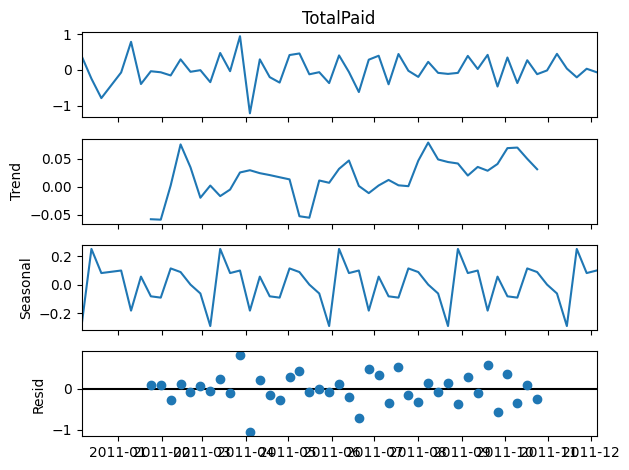

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(log_revenue_diff, period=12)

decomp.plot()
plt.show()

By inspecting the seasonal component of each seasonal decomposition for weeks 4,8 and 12 there clearly is some kind of short-term cyclical pattern even though it does not correspond to a clearly interpretable seasonality.

##SARIMA Model Choice

As established in the previous ARIMA project the non seasonal components for the SARIMA will be SARIMA(0,1,1)(P,D,Q,M) as the ACF shows a significant spike at lag 1 with no further significant spikes, thus suggesting an MA(1) component, while the PACF has no significant spikes indicating no strong autoregressive structure is present. No repeating seasonal spikes have been identified, suggesting weak seasonality.

Therefore, to indentify the most suitable period (4,8, 12 weeks) we have performed a seasonal decomposition on each of the periods. Since each decomposition suggest a seasonality a SARIMA model will be tested for each one of the periods and then compared to the baseline.

##Train test split

To prepare the data into a train/test split a split of 80%/20% have been chosen and the data has been split chronologically, so the first 41 weeks of the year will be used as the training data and the other 11 weeks are used as the test data so the model mimicks a real forecasting scenario.

In [ ]:
train_size = int(len(log_revenue) * 0.80)
train, test = log_revenue[:train_size], log_revenue[train_size:]

## Model Training

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


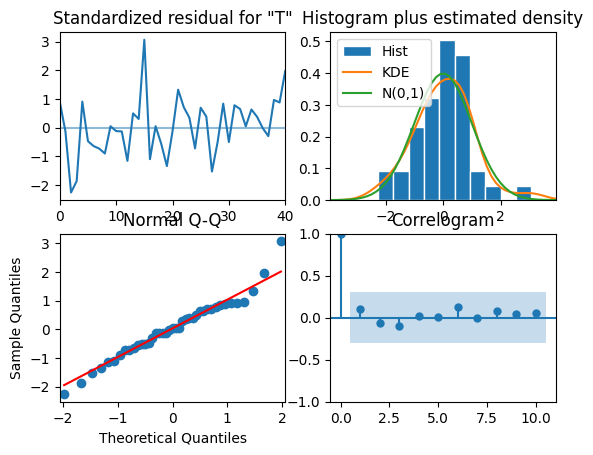

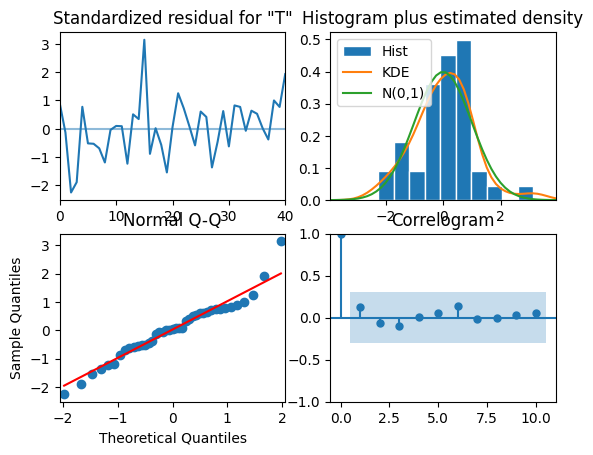

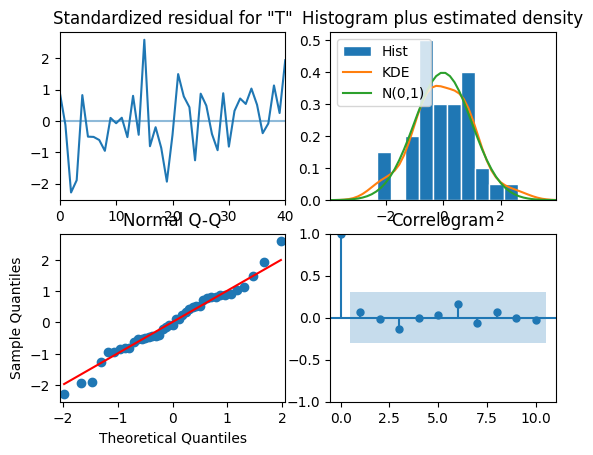

In [ ]:
models = []
results = []
for s in [4,8,12]:
  model = sm.tsa.statespace.SARIMAX(train,order=(0,1,1),seasonal_order=(1,0,0,s))
  result = model.fit()
  result.plot_diagnostics()
  result.summary()
  models.append(model)
  results.append(result)

In [ ]:
from sklearn.metrics import mean_absolute_error
for i in range(len(results)):
  forecast = results[i].get_forecast(steps=len(test))
  pred = forecast.predicted_mean
  print(f"Result {i}: {mean_absolute_error(test,pred)}")

Result 0: 0.4051948077116288
Result 1: 0.37810466859306496
Result 2: 0.4632307923547058


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/u

In [ ]:
forecast = results[1].get_forecast(steps=len(test))
pred = forecast.predicted_mean
conf_int = forecast.conf_int()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Text(0.5, 1.0, 'SARIMA Model Forecast')

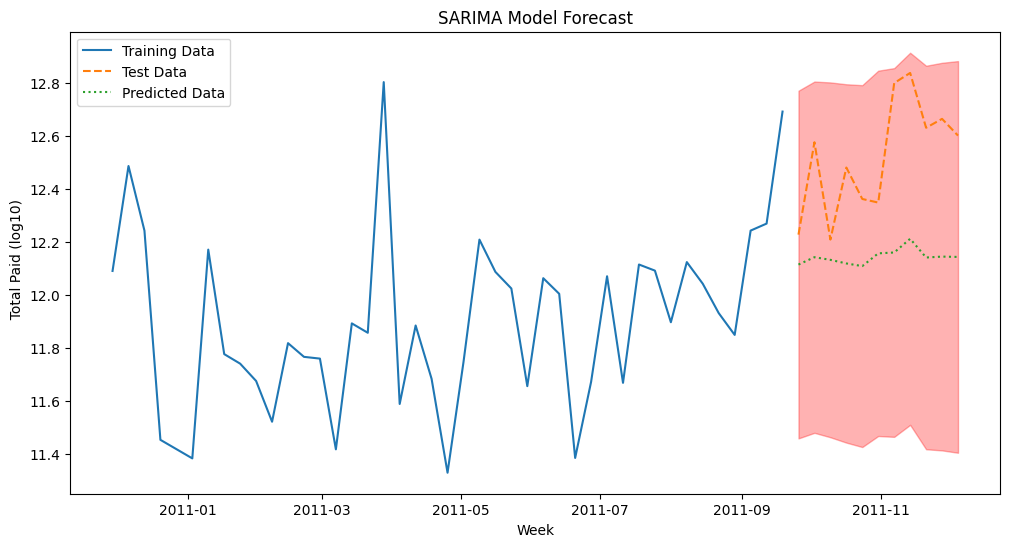

In [ ]:
train.index = pd.to_datetime(train.index)
test.index = pd.to_datetime(test.index)
pred.index = pd.to_datetime(test.index)
conf_int.index = test.index

plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Test Data',linestyle='--')
plt.plot(pred.index, pred, label='Predicted Data',linestyle=':')
plt.fill_between(conf_int.index, conf_int['lower TotalPaid'], conf_int['upper TotalPaid'], color='red', alpha=0.3)
plt.legend()
plt.xlabel('Week')
plt.ylabel('  Total Paid (log10)')
plt.title('SARIMA Model Forecast')

In [ ]:
predictions = []
lower_ci = []
upper_ci = []
model_fit = []
for s in [4,8,12]:
  history = list(train)
  pred = []
  lw_ci = []
  up_ci = []
  model_fitted = None
  for t in range(len(test)):
    model = sm.tsa.statespace.SARIMAX(history,order=(0,1,1),seasonal_order=(1,0,0,s),)
    model_fitted = model.fit()
    forecast = model_fitted.get_forecast(steps=1)
    mean_forecast = forecast.predicted_mean
    conf_interval = forecast.conf_int()
    pred.append(mean_forecast)
    lw_ci.append(conf_interval[0,0])
    up_ci.append(conf_interval[0,1])

    history.append(test[t])
  model_fit.append(model_fitted)
  lower_ci.append(lw_ci)
  upper_ci.append(up_ci)
  predictions.append(pred)

/tmp/ipykernel_1235/1932446248.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  history.append(test[t])


### 4 Week SARIMA

In [ ]:
pred_series = pd.Series(predictions[0], index=test.index)
lower_ci_series = pd.Series(lower_ci[0], index=test.index)
upper_ci_series = pd.Series(upper_ci[0], index=test.index)

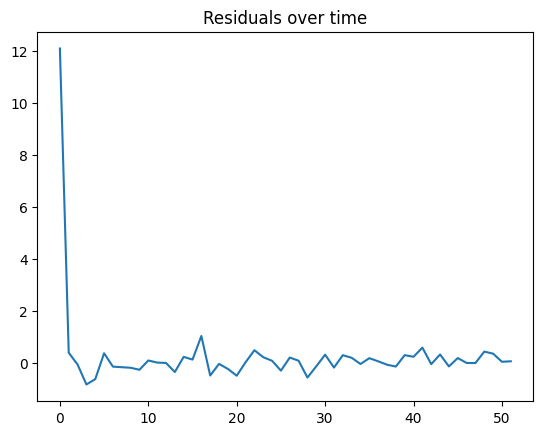

In [ ]:
residuals = pd.DataFrame(model_fit[0].resid)

plt.plot(residuals)
plt.title("Residuals over time")
plt.show()

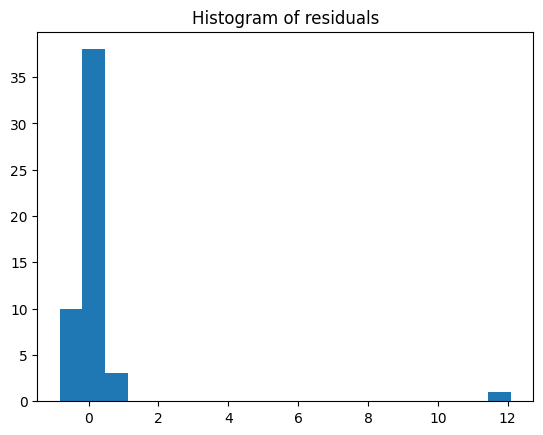

In [ ]:
plt.hist(residuals,bins=20)
plt.title("Histogram of residuals")
plt.show()

In [ ]:
print(model_fit[0].summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                   52
Model:             SARIMAX(0, 1, 1)x(1, 0, [], 4)   Log Likelihood                 -14.897
Date:                            Fri, 15 May 2026   AIC                             35.794
Time:                                    12:13:34   BIC                             41.590
Sample:                                         0   HQIC                            38.009
                                             - 52                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7166      0.120     -5.972      0.000      -0.952      -0.481
ar.S.L4       -0.0315      0.158   

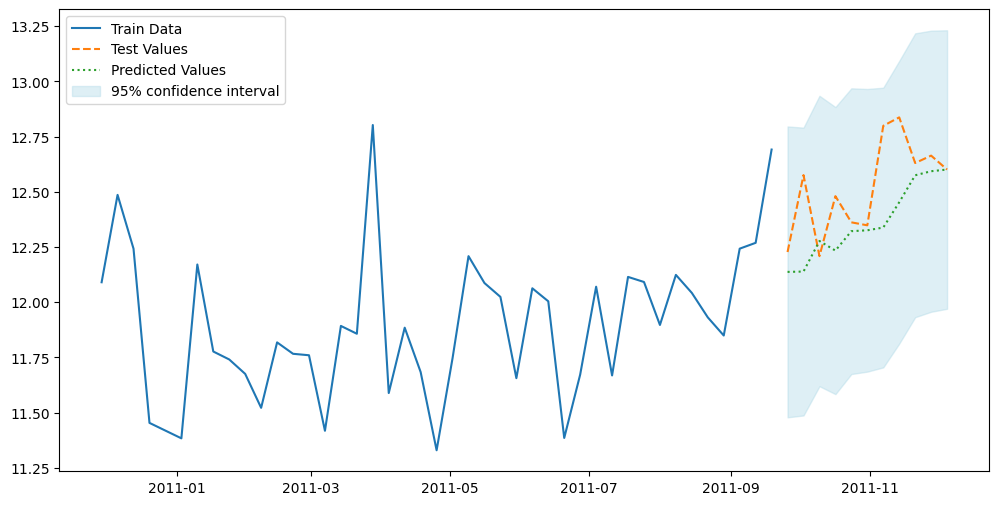

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Train Data')
plt.plot(test.index, test,label='Test Values',linestyle="--")
plt.plot(test.index, pred_series,label='Predicted Values',linestyle=':')
plt.fill_between(test.index, lower_ci_series, upper_ci_series,color='lightblue', alpha=0.4,label="95% confidence interval")
plt.legend()

### 8 Week SARIMA

In [ ]:
pred_series = pd.Series(predictions[1], index=test.index)
lower_ci_series = pd.Series(lower_ci[1], index=test.index)
upper_ci_series = pd.Series(upper_ci[1], index=test.index)

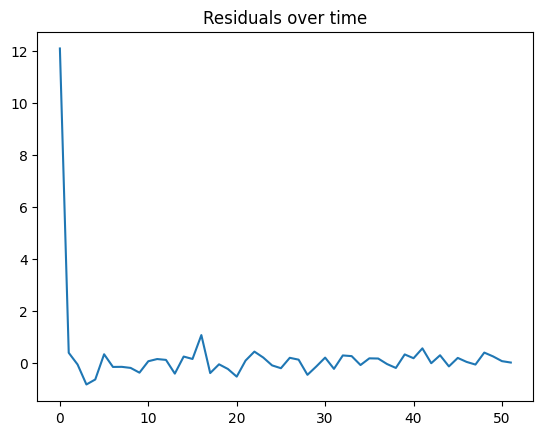

In [ ]:
residuals = pd.DataFrame(model_fit[1].resid)

plt.plot(residuals)
plt.title("Residuals over time")
plt.show()

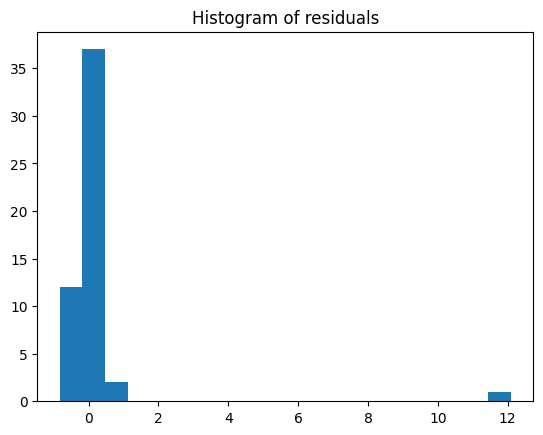

In [ ]:
plt.hist(residuals,bins=20)
plt.title("Histogram of residuals")
plt.show()

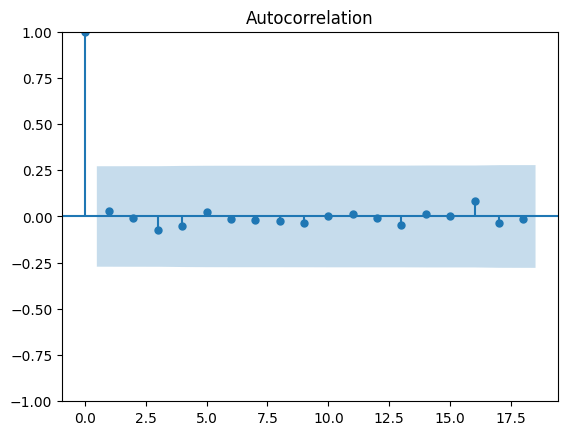

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
errors_df = pd.DataFrame(residuals)
plot_acf(errors_df)
plt.show()

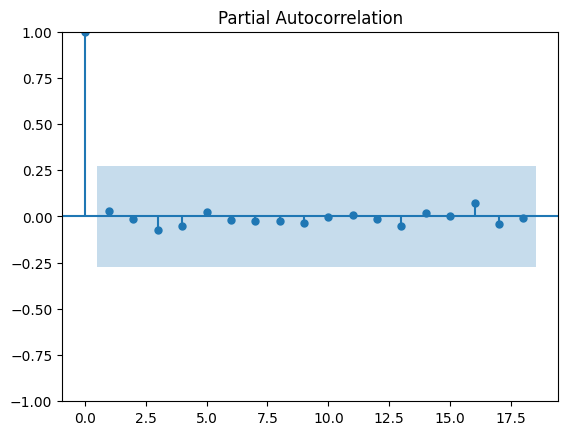

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf
errors_df = pd.DataFrame(residuals)
plot_pacf(errors_df)
plt.show()

In [ ]:
print(model_fit[1].summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                   52
Model:             SARIMAX(0, 1, 1)x(1, 0, [], 8)   Log Likelihood                 -14.119
Date:                            Fri, 15 May 2026   AIC                             34.238
Time:                                    12:13:35   BIC                             40.034
Sample:                                         0   HQIC                            36.453
                                             - 52                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7439      0.127     -5.844      0.000      -0.993      -0.494
ar.S.L8        0.1955      0.184   

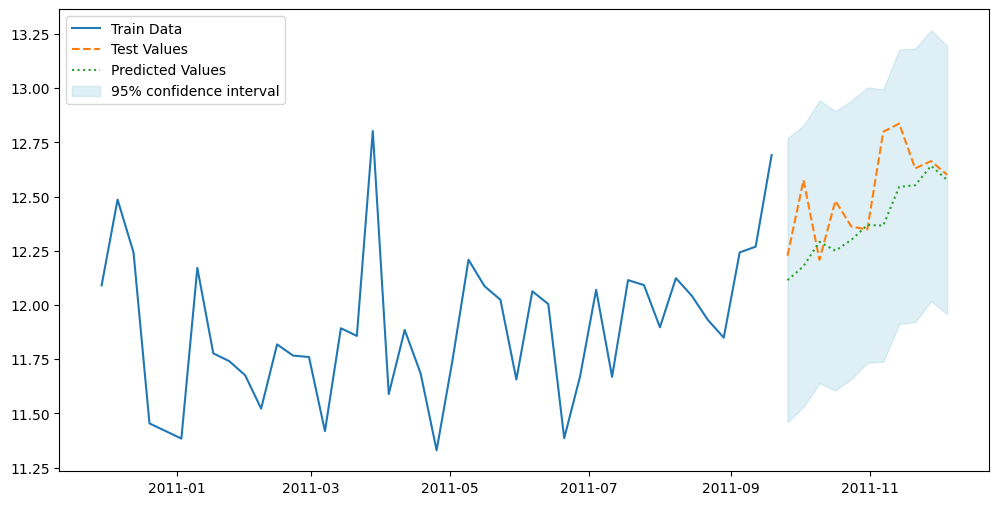

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Train Data')
plt.plot(test.index, test,label='Test Values',linestyle="--")
plt.plot(test.index, pred_series,label='Predicted Values',linestyle=':')
plt.fill_between(test.index, lower_ci_series, upper_ci_series,color='lightblue', alpha=0.4,label="95% confidence interval")
plt.legend()

### 12 Week SARIMA

In [ ]:
pred_series = pd.Series(predictions[2], index=test.index)
lower_ci_series = pd.Series(lower_ci[2], index=test.index)
upper_ci_series = pd.Series(upper_ci[2], index=test.index)

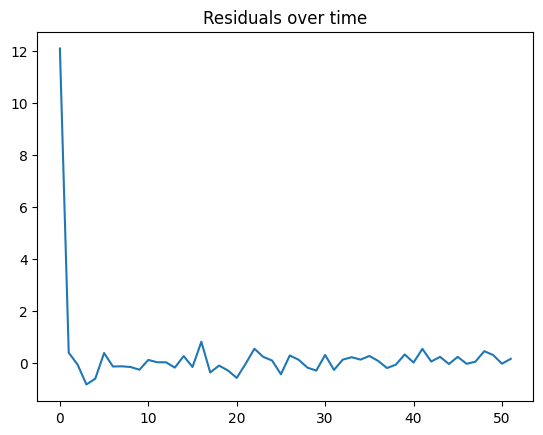

In [ ]:
residuals = pd.DataFrame(model_fit[2].resid)

plt.plot(residuals)
plt.title("Residuals over time")
plt.show()

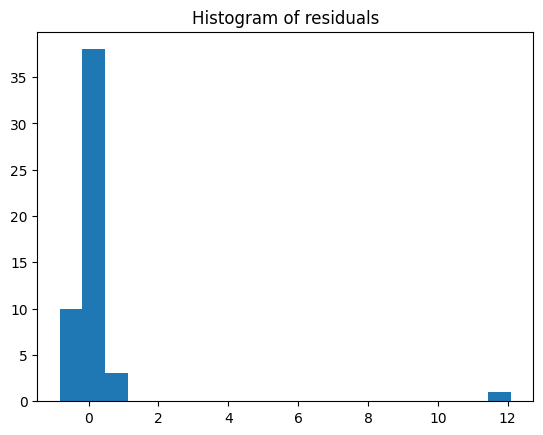

In [ ]:
plt.hist(residuals,bins=20)
plt.title("Histogram of residuals")
plt.show()

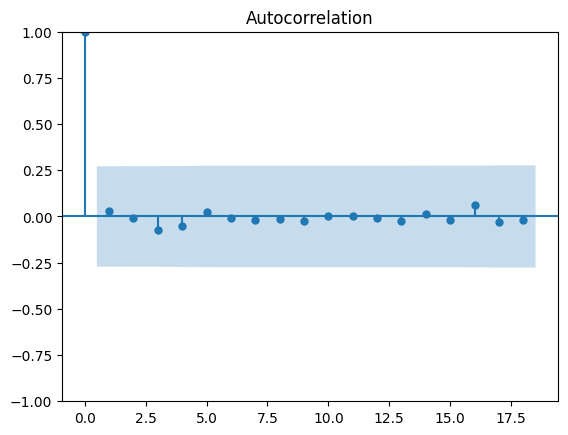

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
errors_df = pd.DataFrame(residuals)
plot_acf(errors_df)
plt.show()

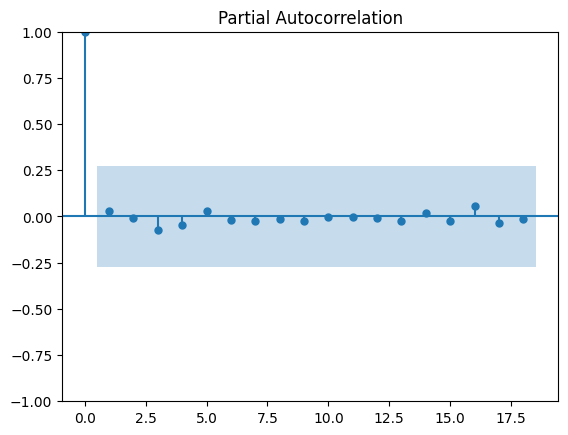

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf
errors_df = pd.DataFrame(residuals)
plot_pacf(errors_df)
plt.show()

In [ ]:
print(model_fit[2].summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                   52
Model:             SARIMAX(0, 1, 1)x(1, 0, [], 12)   Log Likelihood                 -11.825
Date:                             Fri, 15 May 2026   AIC                             29.649
Time:                                     12:13:37   BIC                             35.445
Sample:                                          0   HQIC                            31.864
                                              - 52                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.6855      0.124     -5.544      0.000      -0.928      -0.443
ar.S.L12      -0.3754      

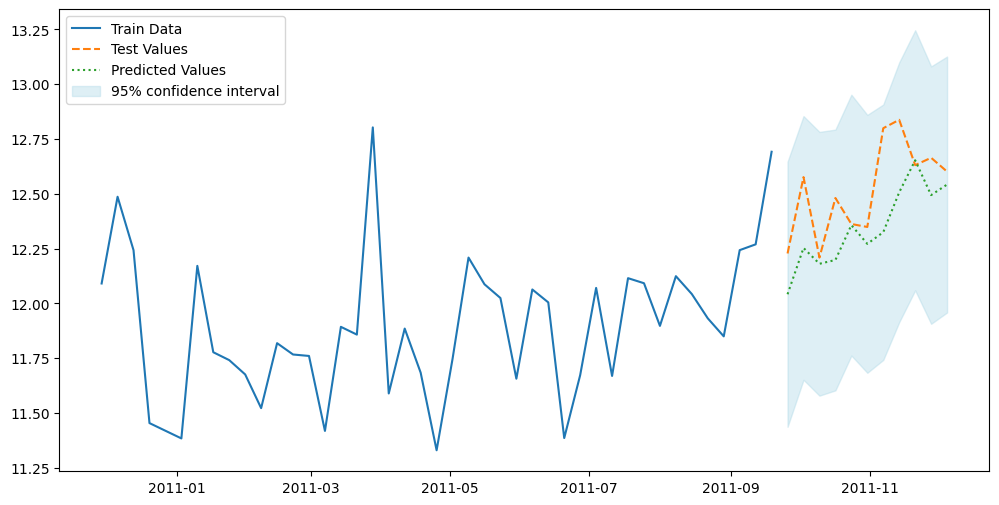

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Train Data')
plt.plot(test.index, test,label='Test Values',linestyle="--")
plt.plot(test.index, pred_series,label='Predicted Values',linestyle=':')
plt.fill_between(test.index, lower_ci_series, upper_ci_series,color='lightblue', alpha=0.4,label="95% confidence interval")
plt.legend()

##Residual Analysis

When inspecting the residuals for each of the periods 4,8 and 12 and their ACF and PACF plots we can deduce that most of the autoregressive structure has been captured by the models with the residuals behaving approximately as white noise. Suggesting the model specification is adequate.

## Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(test, pred)
print("The mean absolute error between the actual revenue and the predicted values from the static SARIMA:",mae)

The mean absolute error between the actual revenue and the predicted values from the static SARIMA: 0.17805074504024143


In [ ]:
mae = mean_absolute_error(test, pred_series)
for i in range(len(predictions)):
  mae = mean_absolute_error(test, predictions[i])
  print("The mean absolute error between the actual revenue and the predicted values from the walk-forward SARIMA:",mae)



The mean absolute error between the actual revenue and the predicted values from the walk-forward SARIMA: 0.17052783875814595
The mean absolute error between the actual revenue and the predicted values from the walk-forward SARIMA: 0.1592923539707236
The mean absolute error between the actual revenue and the predicted values from the walk-forward SARIMA: 0.17805074504024143


In [ ]:
from sklearn.metrics import root_mean_squared_error
rmse =  0
for i in range(len(predictions)):
  rmse = root_mean_squared_error(test, predictions[i])
  print("The root mean squared error between the actual revenue and the predicted values from the walk-forward SARIMA:",rmse)

The root mean squared error between the actual revenue and the predicted values from the walk-forward SARIMA: 0.2401790929291327
The root mean squared error between the actual revenue and the predicted values from the walk-forward SARIMA: 0.21601929423365723
The root mean squared error between the actual revenue and the predicted values from the walk-forward SARIMA: 0.23219927034650364


Model | Seasonal Period | MAE | RMSE
------------|---------------|----------|-----------
ARIMA| None| 0.170 | 0.236          
SARIMA| 4| 0.171 | 0.240
SARIMA| 8| 0.159 | 0.216
SARIMA| 12| 0.178 | 0.232

As seen in the table above SARIMA with the 8 week seasonal period has a MAE score of 0.159 which is lower than the ARIMA baseline determined in the previous project with a MAE score of 0.170. Although, we have established that the seasonality was not clearly evident, introducing a seasonal component with a period of 8 weeks slightly improved forecasting performance. Thus, this suggests the presence of short-term cyclical dependencies rather than long-term seasonality which were not fully captured by the non seasonal ARIMA.

## Limitations

As the data spans only a single year it limits the ability to reliably identify long-term seasonal patterns. Especially, as this is a retail based dataset the revenue may be influenced by irregular events such as holiday seasons or promotions rather than stable seasonal cycles. Therefore, even though the selected seasonal period improved forecasting performance empirically, there was no strong seasonal structure clearly present in the ACF/PACF analysis.

## Future Work

Based on the findings in this project the future steps are to develop SARIMAX models and compare them to the SARIMA model found in this project and explore holiday/event-based forecasting features which then will lead to exploration of machine learning solutions.